# *The Wisdom of Crowds*

Vamos a comenzar la Unidad 3 con un experimento...


# Experimento: ¿cuántas tapitas hay en el frasco?

## *The Wisdom of Crowds*

*The Wisdom of Crowds: Why the Many Are Smarter Than the Few and How Collective Wisdom Shapes
Business, Economies, Societies and Nations* es un libro publicado en 2004 por **James Surowiecki**.

Su idea central es que, bajo determinadas condiciones, la agregación de estimaciones realizadas
por muchas personas puede producir una respuesta colectiva muy buena, incluso cuando las
estimaciones individuales presentan bastante error.

Surowiecki destaca cuatro condiciones para que una multitud pueda comportarse de manera
“sabia”:

1. **Diversidad de opiniones:** las personas aportan perspectivas o información diferente.
2. **Independencia:** cada persona realiza su estimación sin estar condicionada por las demás.
3. **Descentralización:** las personas pueden apoyarse en su conocimiento o criterio local.
4. **Agregación:** existe un mecanismo para combinar las respuestas individuales.

Fuente de referencia: [The Wisdom of Crowds — Wikipedia](https://en.wikipedia.org/wiki/The_Wisdom_of_Crowds)


## Francis Galton y el peso del buey

El libro comienza con una anécdota vinculada con el científico y estadístico británico
**Francis Galton**.

En una feria realizada en Plymouth, cientos de participantes intentaron estimar el peso de un
buey faenado. Galton analizó las estimaciones y observó que el valor agregado de la multitud
resultaba sorprendentemente cercano al valor real.

El caso es particularmente interesante para esta clase porque convierte un conjunto de
**estimaciones individuales** en un problema de datos:

- ¿Cómo representamos las respuestas?
- ¿Qué valor representa mejor al grupo?
- ¿Media o mediana?
- ¿Qué tan dispersas están las respuestas?
- ¿Existen valores atípicos?
- ¿Qué ocurre si las personas conocen previamente la opinión del resto?

> Nuestro experimento reemplaza el peso del buey por una pregunta más simple:
> **¿cuántas tapitas de plástico hay dentro del frasco?**

Referencia: [The Wisdom of Crowds](https://en.wikipedia.org/wiki/The_Wisdom_of_Crowds)


## Diseño del experimento

Realizaremos **dos rondas**.

### Round 1 — estimación independiente

Cada estudiante observa el frasco y completa individualmente un Google Form.

**Importante:** no se deben compartir estimaciones antes de cerrar esta ronda.

El objetivo es preservar la condición de **independencia**. Las respuestas serán almacenadas
en la pestaña `round_1` de un Google Spreadsheet.

Luego analizaremos la distribución y calcularemos la **media** y la **mediana** del grupo.

### Round 2 — estimación después de conocer al grupo

Después de mostrar los resultados agregados de la primera ronda, cada estudiante realizará una
segunda estimación. Las respuestas estarán disponibles en `round_2`.

En esta segunda ronda la independencia ya no es completa: todos conocen información acerca de
la opinión del grupo.

Esto nos permitirá investigar una nueva pregunta:

> **¿Conocer la estimación colectiva mejora necesariamente la decisión de la multitud?**


In [18]:
# Librerías necesarias para el experimento

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import quote


In [19]:
# ============================================================
# CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

# Reemplazar por el ID real del Google Spreadsheet.
GOOGLE_SHEET_ID = "17sbyXZ-PnDWvfrD863XAn1mdTGatdIXGUpk0j3DH_KE"

ROUND_1_SHEET = "round_1"
ROUND_2_SHEET = "round_2"

# Nombre exacto de la pregunta del formulario que contiene la estimación.
# Por ejemplo: "guess", "Estimación" o "¿Cuántas tapitas hay?"
GUESS_COLUMN = "guess"

# Completar antes de la clase, pero NO revelar todavía a los estudiantes.
TRUE_VALUE = 30


In [20]:
def load_google_sheet_tab(spreadsheet_id, sheet_name):
    """Carga una pestaña pública de Google Sheets como DataFrame."""

    sheet = quote(sheet_name)
    url = (
        f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}"
        f"/gviz/tq?tqx=out:csv&sheet={sheet}"
    )

    return pd.read_csv(url)


# Round 1 — levantar las estimaciones

Cerrar primero el formulario de la primera ronda. Recién entonces ejecutar las siguientes
celdas.

Antes de calcular cualquier estadística conviene **mirar los datos**: esta es justamente una
de las primeras prácticas de EDA.


In [21]:
df_round_1_raw = load_google_sheet_tab(
    GOOGLE_SHEET_ID,
    ROUND_1_SHEET
)

df_round_1_raw.head(10)


,guess
0,27
1,29
2,21
3,24
4,18
5,28
6,26
7,22
8,17
9,19


In [22]:
# Primera inspección

print("Shape:", df_round_1_raw.shape)
print()
df_round_1_raw.info()


Shape: (40, 1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   guess   40 non-null     int64
dtypes: int64(1)
memory usage: 452.0 bytes


## Preparar la variable `guess`

Google Forms puede incorporar columnas adicionales, por ejemplo la marca temporal.
Para el experimento sólo necesitamos convertir la respuesta elegida en una variable numérica.

`errors="coerce"` transforma respuestas no numéricas en `NaN`. Esto nos permite discutir una
primera dimensión de calidad de datos: **validez**.


In [23]:
df_round_1 = df_round_1_raw.copy()

df_round_1["guess"] = pd.to_numeric(
    df_round_1[GUESS_COLUMN],
    errors="coerce"
)

# Una cantidad de tapitas debe ser positiva.
df_round_1.loc[df_round_1["guess"] <= 0, "guess"] = pd.NA

df_round_1[["guess"]].head()


,guess
0,27.0
1,29.0
2,21.0
3,24.0
4,18.0


In [24]:
# ¿Tenemos respuestas inválidas o faltantes?

df_round_1["guess"].isnull().sum()


np.int64(0)

In [25]:
# Trabajamos únicamente con respuestas válidas para los cálculos.

guesses_1 = df_round_1["guess"].dropna()

print("Cantidad de respuestas válidas:", guesses_1.count())
print("Media:   ", round(guesses_1.mean(), 2))
print("Mediana: ", round(guesses_1.median(), 2))
print("Mínimo:  ", guesses_1.min())
print("Máximo:  ", guesses_1.max())
print("Desvío estándar:", round(guesses_1.std(), 2))


Cantidad de respuestas válidas: 40
Media:    27.12
Mediana:  24.5
Mínimo:   15.0
Máximo:   45.0
Desvío estándar: 8.74


## Pregunta para la clase

Antes de revelar el valor real:

> **¿Qué valor utilizarían como estimación colectiva: la media o la mediana? ¿Por qué?**

La respuesta no debería decidirse solamente observando ambos números. Primero conviene analizar
la **distribución** de las estimaciones y detectar si existen valores extremos.


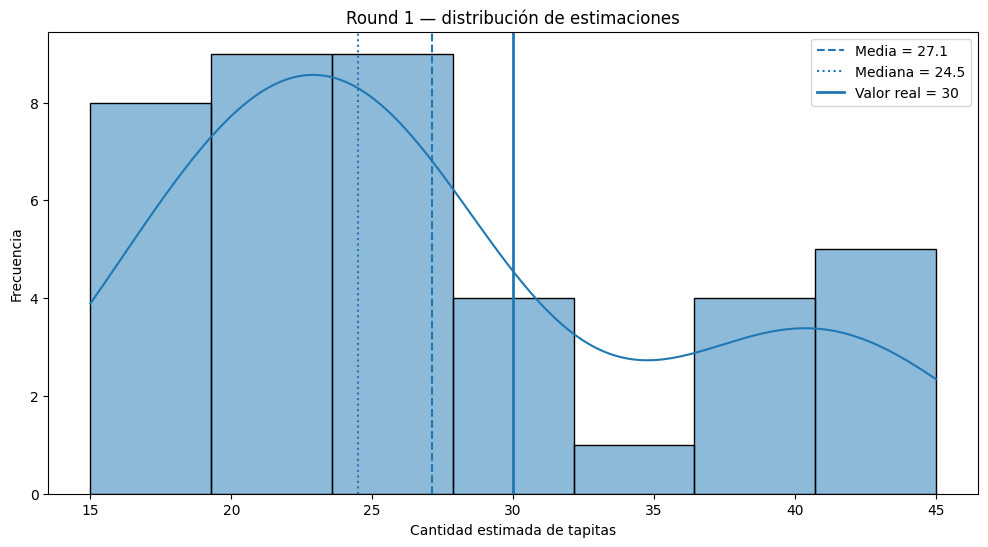

In [26]:
# Histograma de las estimaciones del Round 1

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_round_1,
    x="guess",
    bins="auto",
    kde=True
)

plt.axvline(
    guesses_1.mean(),
    linestyle="--",
    label=f"Media = {guesses_1.mean():.1f}"
)

plt.axvline(
    guesses_1.median(),
    linestyle=":",
    label=f"Mediana = {guesses_1.median():.1f}"
)

if TRUE_VALUE is not None:
    plt.axvline(
        TRUE_VALUE,
        linewidth=2,
        label=f"Valor real = {TRUE_VALUE}"
    )

plt.title("Round 1 — distribución de estimaciones")
plt.xlabel("Cantidad estimada de tapitas")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


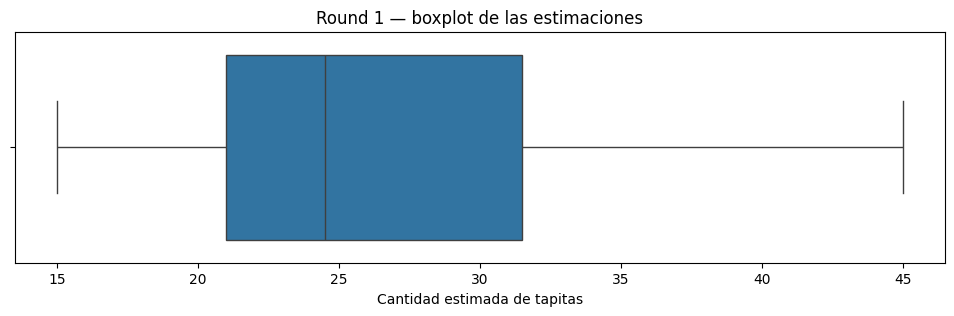

In [27]:
# Boxplot: una forma compacta de observar centro, dispersión y posibles outliers.

plt.figure(figsize=(12, 3))

sns.boxplot(
    data=df_round_1,
    x="guess"
)

plt.title("Round 1 — boxplot de las estimaciones")
plt.xlabel("Cantidad estimada de tapitas")
plt.show()


## Revelar el resultado del Round 1

En este punto mostramos al curso:

- cantidad de respuestas,
- media,
- mediana,
- histograma,
- boxplot.

**Todavía no es necesario revelar el número verdadero de tapitas.**

Ahora los estudiantes completan el formulario correspondiente al `round_2`.

La segunda estimación se realiza con nueva información disponible: la opinión agregada del
grupo. Por lo tanto, podemos esperar que muchas respuestas se acerquen entre sí.


# Round 2 — ¿qué ocurre cuando dejamos de ser completamente independientes?

Una vez cerrado el segundo formulario, cargamos la pestaña `round_2`.

No sobrescribimos los datos del Round 1: conservar ambas versiones es importante para hacer
comparaciones reproducibles.


In [28]:
df_round_2_raw = load_google_sheet_tab(
    GOOGLE_SHEET_ID,
    ROUND_2_SHEET
)

df_round_2 = df_round_2_raw.copy()

df_round_2["guess"] = pd.to_numeric(
    df_round_2[GUESS_COLUMN],
    errors="coerce"
)

df_round_2.loc[df_round_2["guess"] <= 0, "guess"] = pd.NA

guesses_2 = df_round_2["guess"].dropna()

print("Cantidad de respuestas válidas:", guesses_2.count())
print("Media:   ", round(guesses_2.mean(), 2))
print("Mediana: ", round(guesses_2.median(), 2))
print("Desvío estándar:", round(guesses_2.std(), 2))


Cantidad de respuestas válidas: 30
Media:    33.5
Mediana:  26.0
Desvío estándar: 22.09


In [29]:
# Construimos un DataFrame en formato largo para comparar ambas rondas.

comparison = pd.concat(
    [
        pd.DataFrame({"round": "Round 1", "guess": guesses_1}),
        pd.DataFrame({"round": "Round 2", "guess": guesses_2})
    ],
    ignore_index=True
)

comparison.head()


,round,guess
0,Round 1,27.0
1,Round 1,29.0
2,Round 1,21.0
3,Round 1,24.0
4,Round 1,18.0


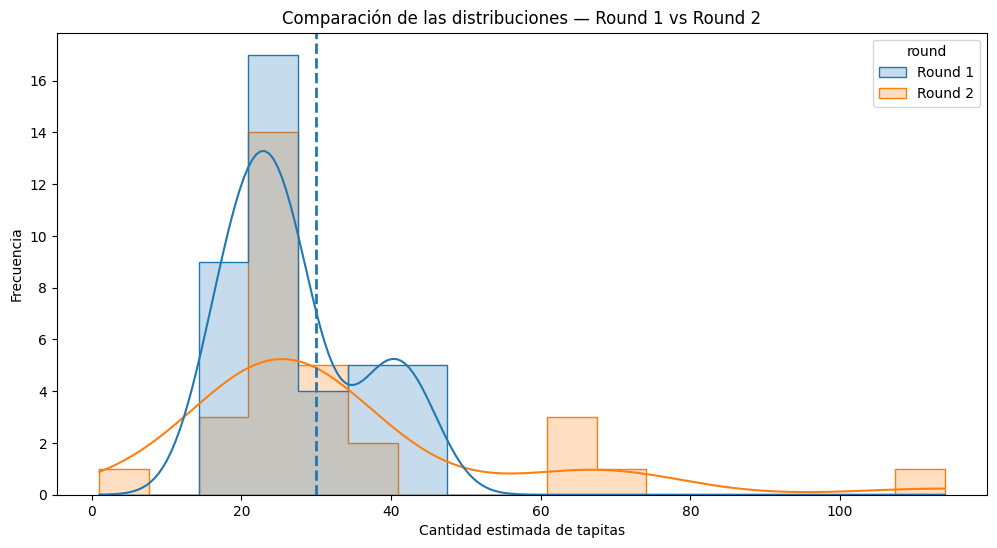

In [30]:
# Comparación visual de ambas distribuciones

plt.figure(figsize=(12, 6))

sns.histplot(
    data=comparison,
    x="guess",
    hue="round",
    bins="auto",
    kde=True,
    element="step"
)

if TRUE_VALUE is not None:
    plt.axvline(
        TRUE_VALUE,
        linestyle="--",
        linewidth=2,
        label=f"Valor real = {TRUE_VALUE}"
    )

plt.title("Comparación de las distribuciones — Round 1 vs Round 2")
plt.xlabel("Cantidad estimada de tapitas")
plt.ylabel("Frecuencia")
plt.show()


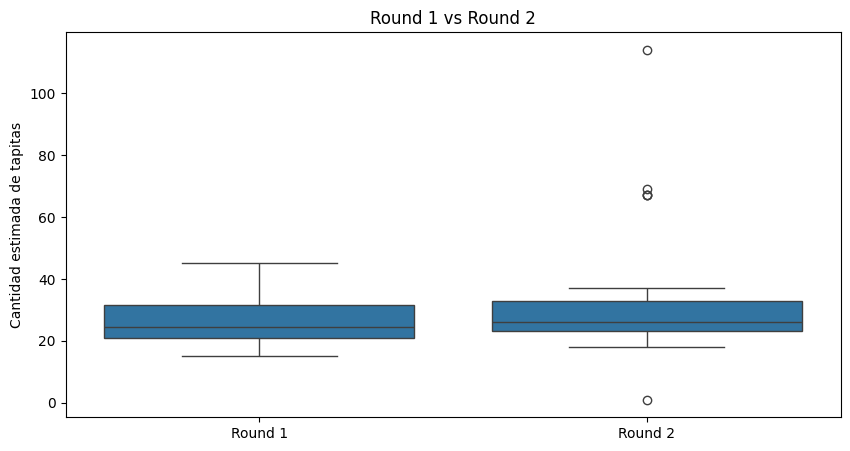

In [31]:
# Boxplots comparativos

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=comparison,
    x="round",
    y="guess"
)

plt.title("Round 1 vs Round 2")
plt.xlabel("")
plt.ylabel("Cantidad estimada de tapitas")
plt.show()


In [32]:
# Tabla resumen de ambas rondas

summary = (
    comparison
    .groupby("round")["guess"]
    .agg(
        respuestas="count",
        media="mean",
        mediana="median",
        desvio="std",
        minimo="min",
        maximo="max"
    )
    .round(2)
)

summary


,respuestas,media,mediana,desvio,minimo,maximo
round,,,,,,
Round 1,40,27.12,24.5,8.74,15.0,45.0
Round 2,30,33.50,26.0,22.09,1.0,114.0


# Momento de revelar el valor real

Ahora sí revelamos cuántas tapitas había realmente en el frasco.

Además de estudiar la dispersión de las respuestas, podemos medir directamente el **error**
de la estimación colectiva.


In [33]:
if TRUE_VALUE is None:
    print("⚠️ Completar TRUE_VALUE en la celda de configuración para calcular los errores.")
else:
    results = pd.DataFrame({
        "round": ["Round 1", "Round 2"],
        "mean": [guesses_1.mean(), guesses_2.mean()],
        "median": [guesses_1.median(), guesses_2.median()]
    })

    results["mean_abs_error"] = (results["mean"] - TRUE_VALUE).abs()
    results["median_abs_error"] = (results["median"] - TRUE_VALUE).abs()

    display(results.round(2))


,round,mean,median,mean_abs_error,median_abs_error
0,Round 1,27.12,24.5,2.88,5.5
1,Round 2,33.50,26.0,3.50,4.0


In [34]:
# Error individual respecto del valor verdadero.

if TRUE_VALUE is not None:
    comparison_with_error = comparison.copy()
    comparison_with_error["absolute_error"] = (
        comparison_with_error["guess"] - TRUE_VALUE
    ).abs()

    error_summary = (
        comparison_with_error
        .groupby("round")["absolute_error"]
        .agg(
            error_medio="mean",
            error_mediano="median"
        )
        .round(2)
    )

    display(error_summary)


,error_medio,error_mediano
round,,
Round 1,8.18,8.0
Round 2,13.37,6.0


## Preguntas para discutir

1. ¿La media y la mediana del Round 1 quedaron cerca del valor verdadero?
2. ¿Alguna persona estuvo más cerca que la estimación colectiva?
3. ¿Había valores atípicos? ¿Cómo afectaron a la media?
4. ¿La mediana fue más robusta frente a esos valores?
5. ¿Las respuestas del Round 2 quedaron más concentradas?
6. ¿Disminuyó el desvío estándar?
7. ¿El Round 2 fue realmente **más preciso**, o solamente produjo mayor consenso?
8. ¿La pérdida de independencia ayudó o perjudicó?
9. ¿Qué ocurriría si antes del Round 1 el docente dijera una cifra al azar?
10. ¿Qué diferencia existe entre **consenso** y **exactitud**?

La idea central es importante para Ciencia de Datos:

> Una distribución más concentrada no implica necesariamente que los datos estén más cerca de
> la realidad.


# Del experimento a la calidad de los datos

Nuestro pequeño dataset permite conectar *Wisdom of Crowds* con dimensiones de calidad:

| Dimensión | Pregunta en nuestro experimento |
|---|---|
| **Precisión** | ¿Qué tan cerca están las estimaciones del número real de tapitas? |
| **Completitud** | ¿Respondieron todos los estudiantes? |
| **Consistencia** | ¿Todas las respuestas representan la misma magnitud y están registradas de la misma forma? |
| **Validez** | ¿Hay respuestas imposibles, texto en lugar de números o cantidades negativas? |
| **Relevancia** | ¿Las variables recolectadas sirven para responder la pregunta del experimento? |

